# Visualizing the MT with Seaborn

In [1]:
import pandas as pd
import seaborn as sns

I have made a very simple query:

```
clause
  word lex* g_cons* vt* vs* sp* nu* gn* ps* language*
```

I ran this query in the TF Browser app and exported the results. You can find the resulting file in this folder: the_whole_mt.tsv. 
Let's import the dataset in Python with Pandas.

In [17]:
mt = pd.read_csv('the_whole_mt.tsv', encoding='utf16', sep='\t')

How many rows and columns does the dataset have?

In [15]:
mt.shape

(426590, 19)

Inspect the first 5 rows.

In [16]:
mt.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,gn2,language2,lex2,nu2,ps2,sp2,vs2,vt2
0,1,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,1,word,בְּ,B,NaN,Hebrew,B,NaN,NaN,prep,NaN,NaN
1,2,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,2,word,רֵאשִׁ֖ית,R>CJT,f,Hebrew,R>CJT/,sg,NaN,subs,NaN,NaN
2,3,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,3,word,בָּרָ֣א,BR>,m,Hebrew,BR>[,sg,p3,verb,qal,perf
3,4,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,4,word,אֱלֹהִ֑ים,>LHJM,m,Hebrew,>LHJM/,pl,NaN,subs,NaN,NaN
4,5,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,5,word,אֵ֥ת,>T,NaN,Hebrew,>T,NaN,NaN,prep,NaN,NaN


### How many words are there in each book?

In [19]:
word_counts = mt['S1'].value_counts(sort=False)

In [20]:
word_counts

S1
Genesis          28764
Exodus           23748
Leviticus        17099
Numbers          23188
Deuteronomy      20128
Joshua           14526
Judges           14086
1_Samuel         18929
2_Samuel         15612
1_Kings          18685
2_Kings          17307
Isaiah           22931
Jeremiah         29736
Ezekiel          26182
Hosea             3146
Joel              1318
Amos              2780
Obadiah            392
Jonah              985
Micah             1895
Nahum              746
Habakkuk           897
Zephaniah         1037
Haggai             877
Zechariah         4471
Malachi           1187
Psalms           25372
Job              10912
Proverbs          8859
Ruth              1802
Song_of_songs     1682
Ecclesiastes      4233
Lamentations      1945
Esther            4621
Daniel            8072
Ezra              5268
Nehemiah          7842
1_Chronicles     15566
2_Chronicles     19764
Name: count, dtype: int64

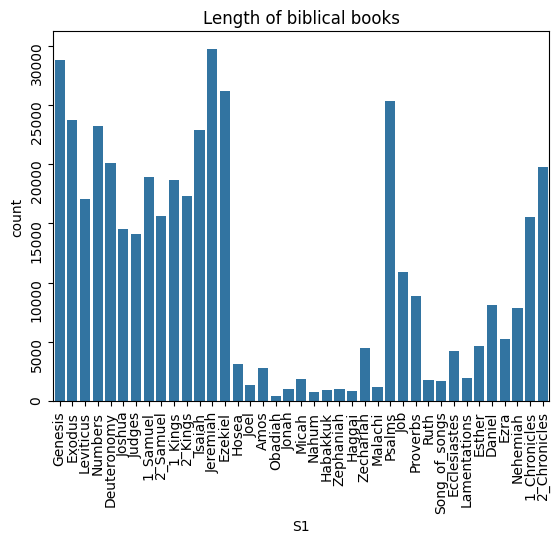

In [67]:
ax = sns.barplot(x=word_counts.index, 
                 y=word_counts, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Length of biblical books')
ax.tick_params(labelrotation=90)

### Which are the most frequently occurring lexemes in the MT?

In [102]:
lex_counts = mt.lex2.value_counts()[:100]

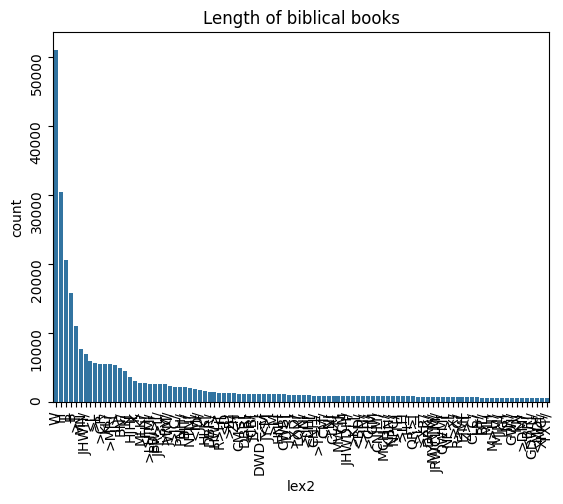

In [103]:
ax = sns.barplot(x=lex_counts.index, 
                 y=lex_counts, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Lexeme frequencies in the MT')
ax.tick_params(labelrotation=90)

### Distribution of אלהים and יהוה in Leviticus

How are אלהים and יהוה  distributed in the book of Leviticus?

In [58]:
god = mt[mt.lex2.isin(['>LHJM/', 'JHWH/'])]
god_in_lev = god[god.S1 == 'Leviticus']

In [59]:
god_in_lev.shape

(364, 19)

In [60]:
god_in_lev.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,gn2,language2,lex2,nu2,ps2,sp2,vs2,vt2
52518,52519,Leviticus,1,1,437873,clause,וַיְדַבֵּ֤ר יְהוָה֙ אֵלָ֔יו מֵאֹ֥הֶל מֹועֵ֖ד,52519,word,יְהוָה֙,JHWH,m,Hebrew,JHWH/,sg,NaN,nmpr,NaN,NaN
52538,52539,Leviticus,1,2,437878,clause,כִּֽי־יַקְרִ֥יב מִכֶּ֛ם קָרְבָּ֖ן לַֽיהוָ֑ה,52539,word,יהוָ֑ה,JHWH,m,Hebrew,JHWH/,sg,NaN,nmpr,NaN,NaN
52571,52572,Leviticus,1,3,437883,clause,אֶל־פֶּ֝תַח אֹ֤הֶל מֹועֵד֙ יַקְרִ֣יב אֹתֹ֔ו לִ...,52572,word,יְהוָֽה׃,JHWH,m,Hebrew,JHWH/,sg,NaN,nmpr,NaN,NaN
52593,52594,Leviticus,1,5,437887,clause,וְשָׁחַ֛ט אֶת־בֶּ֥ן הַבָּקָ֖ר לִפְנֵ֣י יְהוָ֑ה,52594,word,יְהוָ֑ה,JHWH,m,Hebrew,JHWH/,sg,NaN,nmpr,NaN,NaN
52691,52692,Leviticus,1,9,437901,clause,אִשֵּׁ֥ה רֵֽיחַ־נִיחֹ֖וחַ לַֽיהוָֽה׃ ס,52692,word,יהוָֽה׃ ס,JHWH,m,Hebrew,JHWH/,sg,NaN,nmpr,NaN,NaN


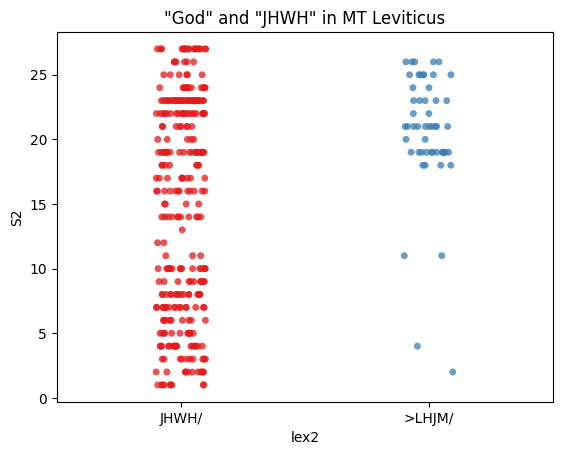

In [61]:
ax = sns.stripplot(y="S2", 
                   x="lex2", 
                   data=god_in_genesis, 
                   hue='lex2',
                   palette="Set1", 
                   edgecolor="blue", 
                   alpha=.75, 
                   size=5
                   ).set(title='"God" and "JHWH" in MT Leviticus')

In [63]:
god_in_lev.lex2.value_counts()

lex2
JHWH/     311
>LHJM/     53
Name: count, dtype: int64

### Which book has the longest average clause length?

In [68]:
mt.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,gn2,language2,lex2,nu2,ps2,sp2,vs2,vt2
0,1,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,1,word,בְּ,B,NaN,Hebrew,B,NaN,NaN,prep,NaN,NaN
1,2,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,2,word,רֵאשִׁ֖ית,R>CJT,f,Hebrew,R>CJT/,sg,NaN,subs,NaN,NaN
2,3,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,3,word,בָּרָ֣א,BR>,m,Hebrew,BR>[,sg,p3,verb,qal,perf
3,4,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,4,word,אֱלֹהִ֑ים,>LHJM,m,Hebrew,>LHJM/,pl,NaN,subs,NaN,NaN
4,5,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,5,word,אֵ֥ת,>T,NaN,Hebrew,>T,NaN,NaN,prep,NaN,NaN


In [71]:
gen = mt[mt.S1 == 'Genesis']

In [74]:
gen.NODE1.value_counts().mean()

np.float64(4.8044095540337395)

In [95]:
mean_lengths = []

all_books = mt.S1.unique()
for book in all_books:
    book_df = mt[mt.S1 == book]
    mean_len = book_df.NODE1.value_counts().mean()
    mean_lengths.append(mean_len)

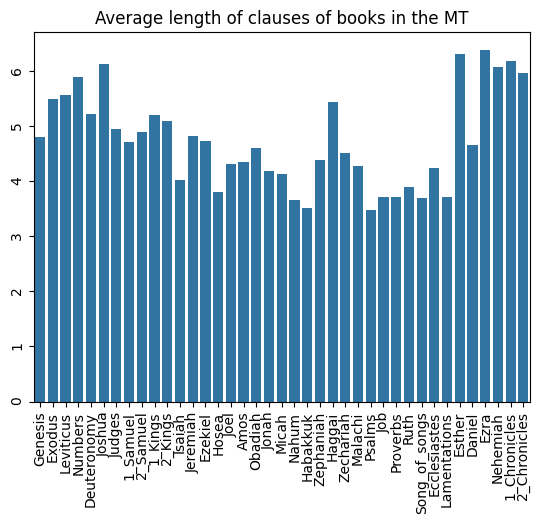

In [94]:
ax = sns.barplot(x=list(all_books), 
                 y=mean_lengths, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Average length of clauses of books in the MT')
ax.tick_params(labelrotation=90)

array(['Genesis', 'Exodus', 'Leviticus', 'Numbers', 'Deuteronomy',
       'Joshua', 'Judges', '1_Samuel', '2_Samuel', '1_Kings', '2_Kings',
       'Isaiah', 'Jeremiah', 'Ezekiel', 'Hosea', 'Joel', 'Amos',
       'Obadiah', 'Jonah', 'Micah', 'Nahum', 'Habakkuk', 'Zephaniah',
       'Haggai', 'Zechariah', 'Malachi', 'Psalms', 'Job', 'Proverbs',
       'Ruth', 'Song_of_songs', 'Ecclesiastes', 'Lamentations', 'Esther',
       'Daniel', 'Ezra', 'Nehemiah', '1_Chronicles', '2_Chronicles'],
      dtype=object)